<a href="https://colab.research.google.com/github/handa12341/UAS-Pengolahan-Citra-Digital/blob/main/Untitled1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Jalankan kode ini di Google Colab
from google.colab import files
import zipfile
import os

# Upload file zip dataset
print("Silakan upload file flowers-recognition.zip")
uploaded = files.upload()

# Ekstrak file zip
for filename in uploaded.keys():
    with zipfile.ZipFile(filename, 'r') as zip_ref:
        zip_ref.extractall('/content/flowers')
    print(f"Dataset {filename} berhasil diekstrak!")

# Cek struktur folder
!ls /content/flowers

Silakan upload file flowers-recognition.zip


Saving archive.zip to archive.zip
Dataset archive.zip berhasil diekstrak!
flowers


In [2]:
# Import semua library yang dibutuhkan
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.datasets import load_digits
import cv2
import os
from PIL import Image
import warnings
warnings.filterwarnings('ignore')

# Set random seed dengan NIM Anda
# Ganti 123456789 dengan NIM Anda
NIM = 123456789  # <-- GANTI DENGAN NIM ANDA
np.random.seed(NIM)

print("Library berhasil diimport!")

Library berhasil diimport!


In [3]:
# Definisikan path ke dataset
dataset_path = '/content/flowers/flowers'  # Sesuaikan dengan struktur folder Anda

# Cek folder yang ada
print("Folder dalam dataset:")
print(os.listdir(dataset_path))

# Definisikan class names
class_names = ['daisy', 'dandelion', 'rose', 'sunflower', 'tulip']

# Hitung jumlah gambar per kelas
for class_name in class_names:
    class_path = os.path.join(dataset_path, class_name)
    if os.path.exists(class_path):
        n_images = len(os.listdir(class_path))
        print(f"Kelas {class_name}: {n_images} gambar")
    else:
        print(f"Folder {class_name} tidak ditemukan!")

Folder dalam dataset:
['tulip', 'sunflower', 'rose', 'daisy', 'dandelion']
Kelas daisy: 764 gambar
Kelas dandelion: 1052 gambar
Kelas rose: 784 gambar
Kelas sunflower: 733 gambar
Kelas tulip: 984 gambar


In [4]:
def extract_features(image_path, target_size=(64, 64)):
    """
    Ekstraksi fitur dari gambar:
    - Resize ke ukuran seragam
    - Konversi ke grayscale
    - Flatten menjadi vektor 1D
    """
    try:
        # Baca gambar
        img = cv2.imread(image_path)
        if img is None:
            return None

        # Konversi ke grayscale
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

        # Resize
        resized = cv2.resize(gray, target_size)

        # Normalisasi pixel (0-1)
        normalized = resized / 255.0

        # Flatten menjadi vektor 1D
        features = normalized.flatten()

        return features
    except Exception as e:
        print(f"Error processing {image_path}: {e}")
        return None

# Tes fungsi dengan satu gambar
sample_class = class_names[0]
sample_path = os.path.join(dataset_path, sample_class)
sample_file = os.listdir(sample_path)[0]
sample_features = extract_features(os.path.join(sample_path, sample_file))

print(f"Contoh ekstraksi fitur:")
print(f"Shape fitur: {sample_features.shape}")
print(f"10 nilai pertama: {sample_features[:10]}")

Contoh ekstraksi fitur:
Shape fitur: (4096,)
10 nilai pertama: [0.87843137 0.90588235 0.91372549 0.90588235 0.89803922 0.85882353
 0.83137255 0.82745098 0.76078431 0.74509804]


In [5]:
def load_dataset(dataset_path, class_names, target_size=(64, 64)):
    """
    Load seluruh dataset dan ekstrak fitur
    """
    X = []  # Features
    y = []  # Labels

    for idx, class_name in enumerate(class_names):
        class_path = os.path.join(dataset_path, class_name)
        if not os.path.exists(class_path):
            print(f"Folder {class_name} tidak ditemukan, dilewati...")
            continue

        print(f"Memproses kelas: {class_name}")
        image_files = os.listdir(class_path)

        for img_file in image_files:
            if img_file.lower().endswith(('.png', '.jpg', '.jpeg')):
                img_path = os.path.join(class_path, img_file)
                features = extract_features(img_path, target_size)

                if features is not None:
                    X.append(features)
                    y.append(idx)

        print(f"  Selesai: {len(image_files)} gambar diproses")

    return np.array(X), np.array(y)

# Load dataset
X, y = load_dataset(dataset_path, class_names)

print(f"\nTotal data: {len(X)} sampel")
print(f"Shape fitur: {X.shape}")
print(f"Distribusi label: {np.bincount(y)}")

Memproses kelas: daisy
  Selesai: 764 gambar diproses
Memproses kelas: dandelion
  Selesai: 1052 gambar diproses
Memproses kelas: rose
  Selesai: 784 gambar diproses
Memproses kelas: sunflower
  Selesai: 733 gambar diproses
Memproses kelas: tulip
  Selesai: 984 gambar diproses

Total data: 4317 sampel
Shape fitur: (4317, 4096)
Distribusi label: [ 764 1052  784  733  984]


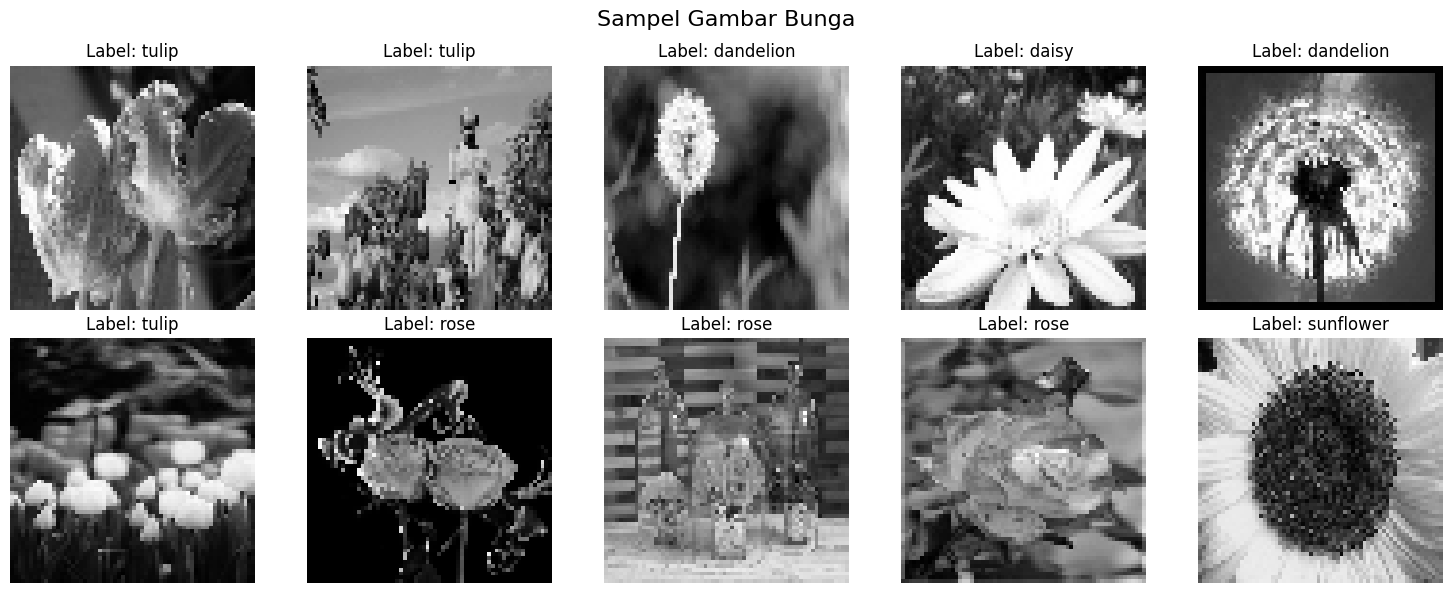

In [6]:
# Visualisasi beberapa gambar sampel
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.ravel()

for i in range(10):
    # Ambil indeks acak
    idx = np.random.randint(len(X))

    # Reshape kembali ke gambar
    img = X[idx].reshape(64, 64)

    axes[i].imshow(img, cmap='gray')
    axes[i].set_title(f'Label: {class_names[y[idx]]}')
    axes[i].axis('off')

plt.suptitle('Sampel Gambar Bunga', fontsize=16)
plt.tight_layout()
plt.show()

In [7]:
# Split data menjadi training (80%) dan testing (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=NIM,  # Menggunakan NIM sebagai random_state
    stratify=y  # Menjaga proporsi kelas
)

print(f"Data Training: {X_train.shape[0]} sampel")
print(f"Data Testing: {X_test.shape[0]} sampel")
print(f"Distribusi training: {np.bincount(y_train)}")
print(f"Distribusi testing: {np.bincount(y_test)}")

Data Training: 3453 sampel
Data Testing: 864 sampel
Distribusi training: [611 842 627 586 787]
Distribusi testing: [153 210 157 147 197]


In [8]:
# Normalisasi fitur menggunakan StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Data berhasil dinormalisasi!")
print(f"Mean training: {X_train_scaled.mean():.4f}")
print(f"Std training: {X_train_scaled.std():.4f}")

Data berhasil dinormalisasi!
Mean training: 0.0000
Std training: 1.0000


In [9]:
# Membangun model MLP
mlp = MLPClassifier(
    hidden_layer_sizes=(100, 50),  # 2 hidden layers dengan 100 dan 50 neuron
    activation='relu',             # Activation function
    solver='adam',                 # Optimizer
    alpha=0.001,                   # Regularization parameter
    batch_size='auto',
    learning_rate='constant',
    learning_rate_init=0.001,
    max_iter=200,                  # Jumlah iterasi maksimum
    random_state=NIM,             # Menggunakan NIM sebagai random_state
    verbose=True                   # Menampilkan progress
)

# Train model
print("Mulai training model MLP...")
mlp.fit(X_train_scaled, y_train)
print("Training selesai!")

Mulai training model MLP...
Iteration 1, loss = 1.89435874
Iteration 2, loss = 1.38091950
Iteration 3, loss = 1.13425091
Iteration 4, loss = 0.94072172
Iteration 5, loss = 0.79543584
Iteration 6, loss = 0.66818355
Iteration 7, loss = 0.59182449
Iteration 8, loss = 0.48221183
Iteration 9, loss = 0.40343887
Iteration 10, loss = 0.32450391
Iteration 11, loss = 0.31979328
Iteration 12, loss = 0.29255351
Iteration 13, loss = 0.22559720
Iteration 14, loss = 0.17431253
Iteration 15, loss = 0.14272931
Iteration 16, loss = 0.12910497
Iteration 17, loss = 0.10733303
Iteration 18, loss = 0.09359520
Iteration 19, loss = 0.12561931
Iteration 20, loss = 0.09386032
Iteration 21, loss = 0.07634130
Iteration 22, loss = 0.07974779
Iteration 23, loss = 0.07294607
Iteration 24, loss = 0.07117328
Iteration 25, loss = 0.08044308
Iteration 26, loss = 0.05045177
Iteration 27, loss = 0.05330638
Iteration 28, loss = 0.03913067
Iteration 29, loss = 0.03364422
Iteration 30, loss = 0.03168034
Iteration 31, loss = 

In [10]:
# Prediksi pada data testing
y_pred = mlp.predict(X_test_scaled)

# Hitung metrik
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print("=" * 50)
print("HASIL EVALUASI MODEL MLP")
print("=" * 50)
print(f"Akurasi: {accuracy:.4f}")
print(f"Precision (weighted): {precision:.4f}")
print(f"Recall (weighted): {recall:.4f}")
print(f"F1-Score (weighted): {f1:.4f}")
print("=" * 50)

# Classification Report detail
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=class_names, digits=4))

HASIL EVALUASI MODEL MLP
Akurasi: 0.2778
Precision (weighted): 0.2884
Recall (weighted): 0.2778
F1-Score (weighted): 0.2756

Classification Report:
              precision    recall  f1-score   support

       daisy     0.2357    0.4052    0.2981       153
   dandelion     0.3233    0.2048    0.2507       210
        rose     0.2171    0.2102    0.2136       157
   sunflower     0.2993    0.2789    0.2887       147
       tulip     0.3408    0.3096    0.3245       197

    accuracy                         0.2778       864
   macro avg     0.2832    0.2817    0.2751       864
weighted avg     0.2884    0.2778    0.2756       864



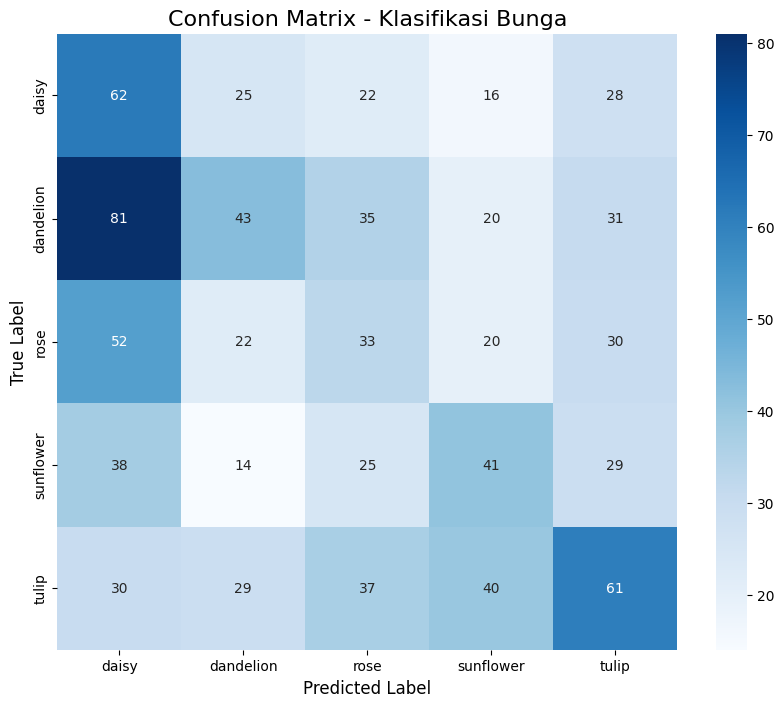

In [11]:
# Buat confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Visualisasi confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.title('Confusion Matrix - Klasifikasi Bunga', fontsize=16)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.show()

In [12]:
def predict_random_images(dataset_path, class_names, model, scaler, n_images_per_class=5):
    """
    Mengambil 5 gambar acak dari setiap kelas dan melakukan prediksi
    """
    all_predictions = []

    for class_idx, class_name in enumerate(class_names):
        class_path = os.path.join(dataset_path, class_name)

        if not os.path.exists(class_path):
            print(f"Folder {class_name} tidak ditemukan!")
            continue

        # Ambil semua file gambar
        image_files = [f for f in os.listdir(class_path)
                      if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

        # Pilih 5 gambar acak
        selected_images = np.random.choice(image_files, n_images_per_class, replace=False)

        for img_file in selected_images:
            img_path = os.path.join(class_path, img_file)

            # Ekstrak fitur
            features = extract_features(img_path)
            if features is not None:
                # Normalisasi
                features_scaled = scaler.transform([features])

                # Prediksi
                pred_class_idx = model.predict(features_scaled)[0]
                pred_class_name = class_names[pred_class_idx]

                # Simpan hasil
                all_predictions.append({
                    'image_path': img_path,
                    'true_class': class_name,
                    'true_idx': class_idx,
                    'pred_class': pred_class_name,
                    'pred_idx': pred_class_idx,
                    'features': features
                })

    return all_predictions

# Generate prediksi untuk 25 gambar acak
predictions = predict_random_images(dataset_path, class_names, mlp, scaler)

print(f"Berhasil memprediksi {len(predictions)} gambar")

Berhasil memprediksi 25 gambar


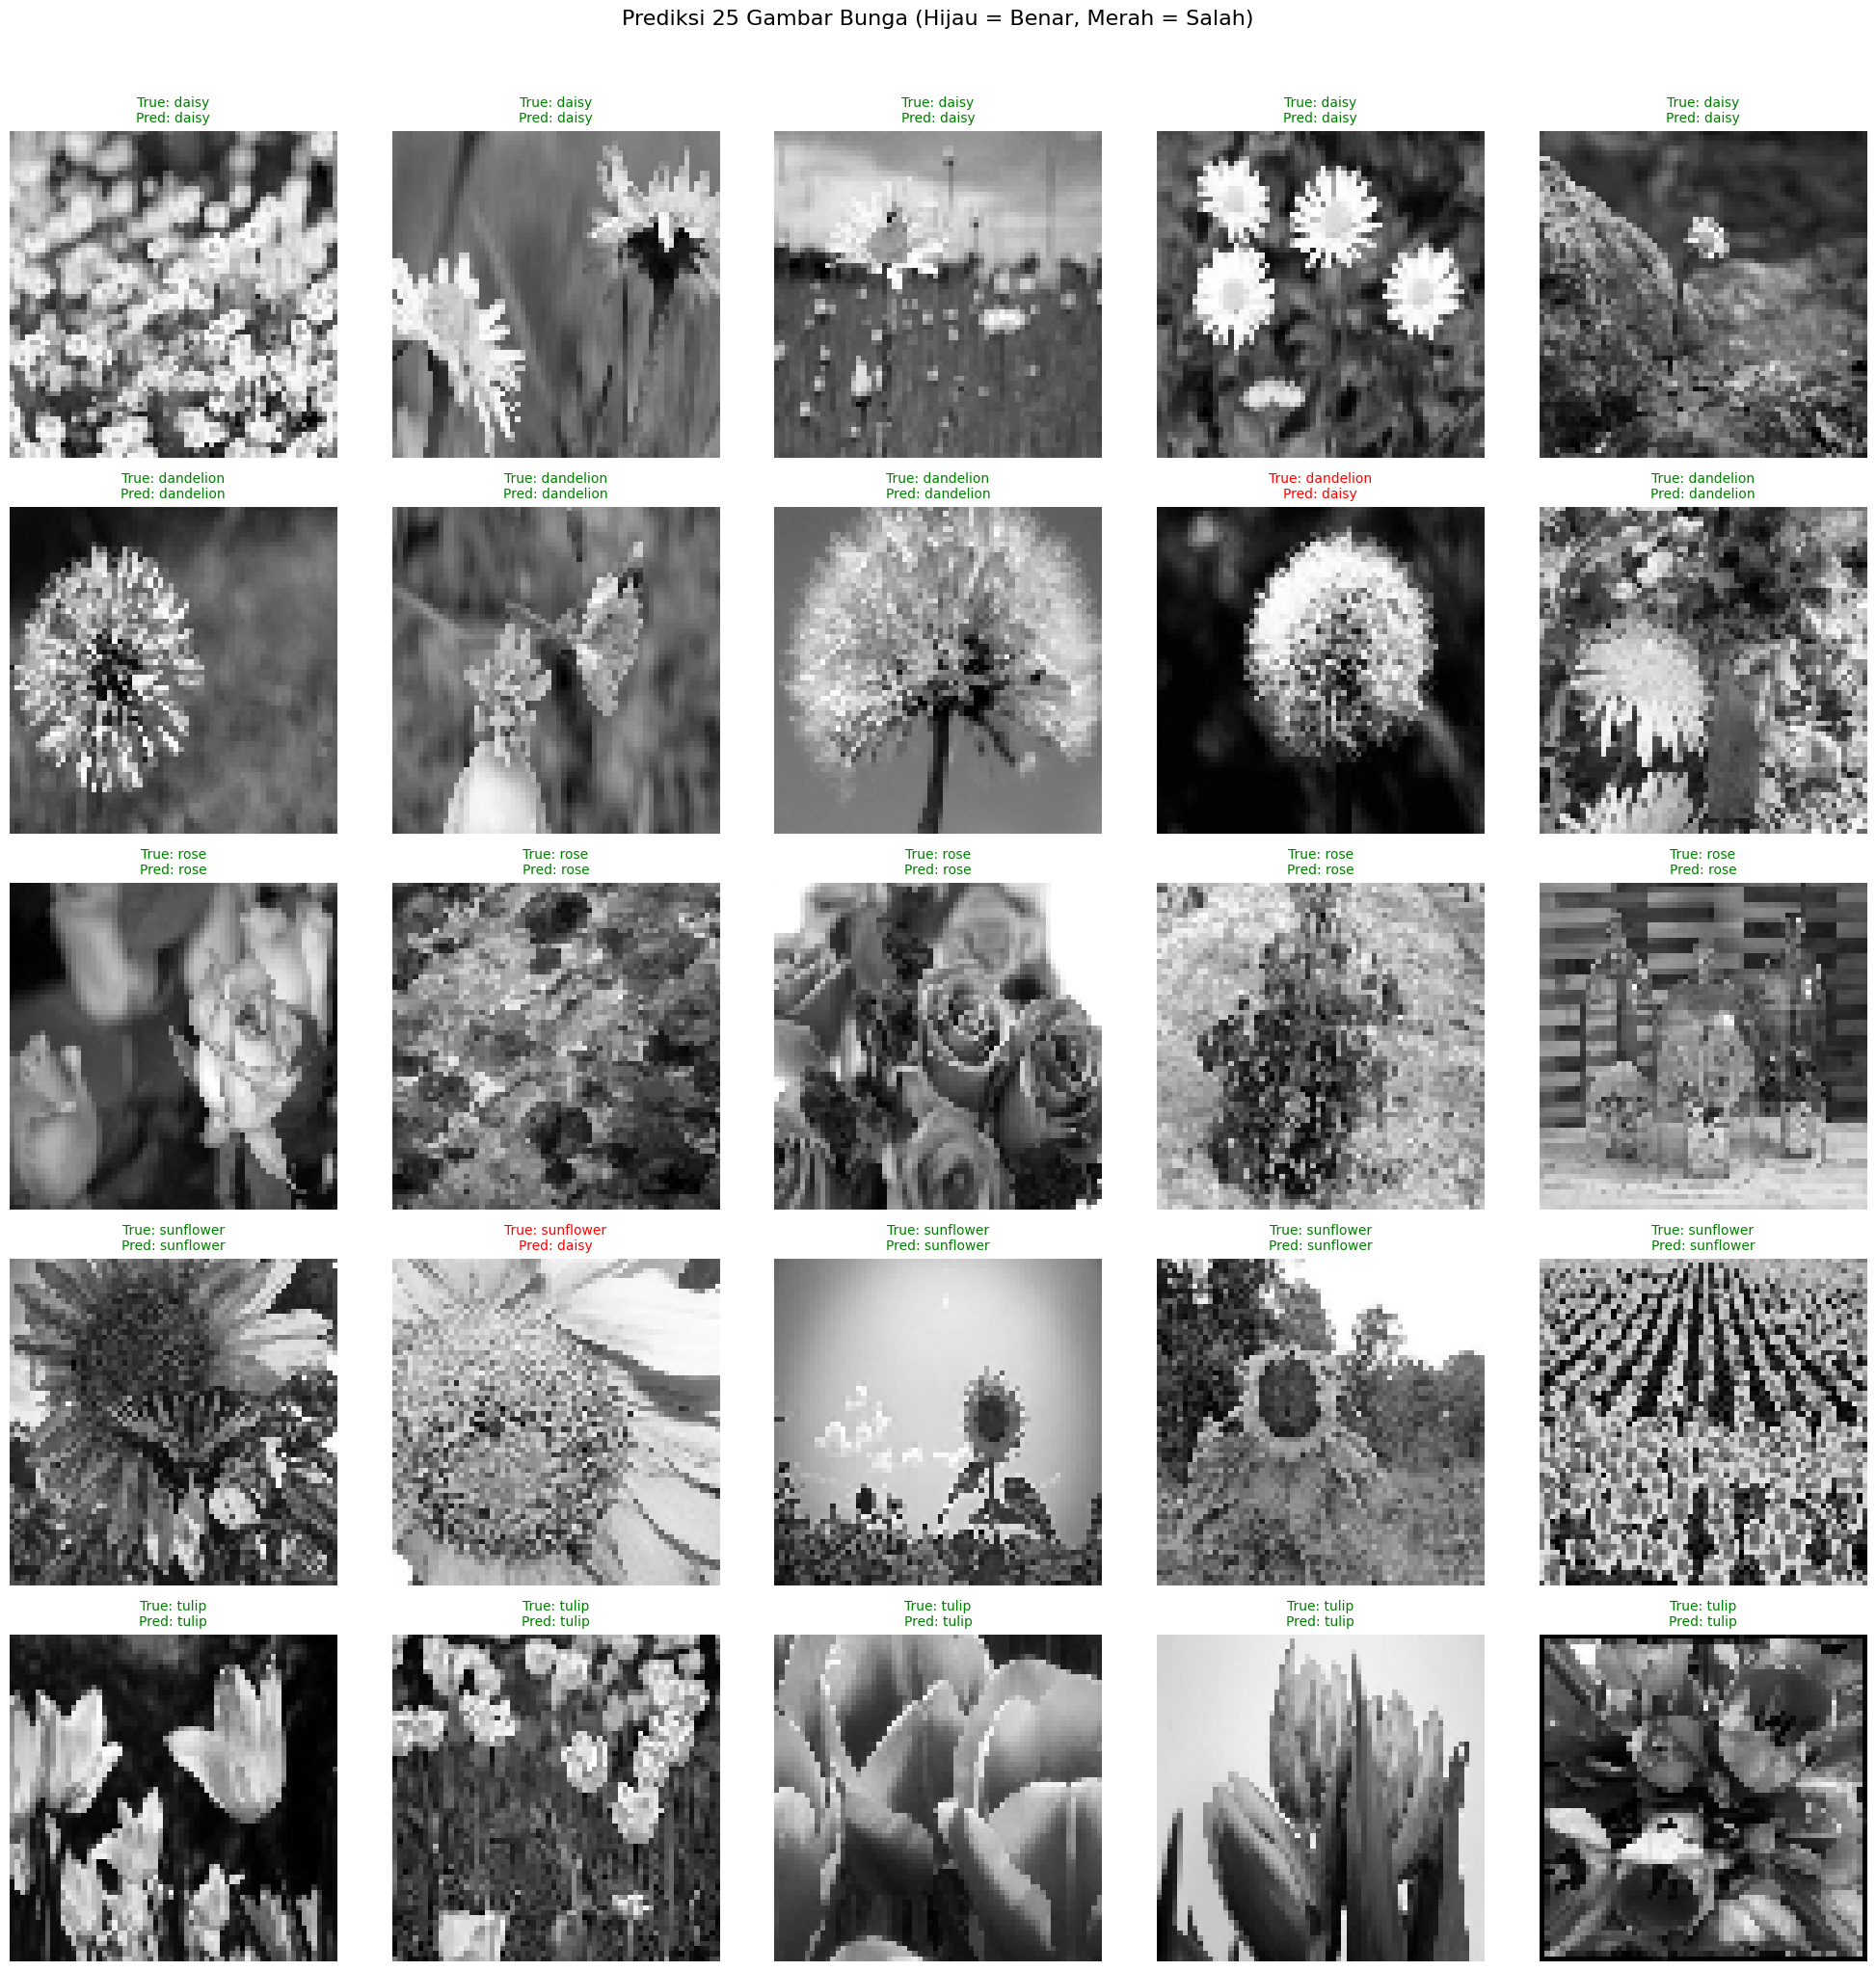

In [13]:
# Visualisasi 25 gambar dengan hasil prediksi
fig, axes = plt.subplots(5, 5, figsize=(20, 20))
axes = axes.ravel()

for i, pred in enumerate(predictions):
    # Reshape fitur ke gambar
    img = pred['features'].reshape(64, 64)

    # Tentukan warna text berdasarkan benar/salah
    is_correct = pred['true_class'] == pred['pred_class']
    color = 'green' if is_correct else 'red'

    # Tampilkan gambar
    axes[i].imshow(img, cmap='gray')

    # Buat title dengan informasi prediksi
    title = f"True: {pred['true_class']}\nPred: {pred['pred_class']}"
    axes[i].set_title(title, fontsize=10, color=color)
    axes[i].axis('off')

plt.suptitle('Prediksi 25 Gambar Bunga (Hijau = Benar, Merah = Salah)',
             fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

In [14]:
# Buat dataframe hasil prediksi
results_df = pd.DataFrame(predictions)
results_df['correct'] = results_df['true_class'] == results_df['pred_class']
results_df['image_name'] = results_df['image_path'].apply(lambda x: os.path.basename(x))

# Tampilkan tabel
print("\nRINGKASAN HASIL PREDIKSI 25 GAMBAR:")
print("=" * 80)
print(results_df[['image_name', 'true_class', 'pred_class', 'correct']].to_string(index=False))

# Hitung akurasi pada 25 gambar
accuracy_25 = results_df['correct'].mean()
print("=" * 80)
print(f"Akurasi pada 25 gambar acak: {accuracy_25*100:.2f}%")


RINGKASAN HASIL PREDIKSI 25 GAMBAR:
                  image_name true_class pred_class  correct
   9120905231_329598304e.jpg      daisy      daisy     True
   8094774544_35465c1c64.jpg      daisy      daisy     True
 2581171297_b0a249b92b_n.jpg      daisy      daisy     True
33891703033_822f7810ce_n.jpg      daisy      daisy     True
15760153042_a2a90e9da5_m.jpg      daisy      daisy     True
 4571923094_b9cefa9438_n.jpg  dandelion  dandelion     True
  13887066460_64156a9021.jpg  dandelion  dandelion     True
 5768217474_f6b1eef6d5_n.jpg  dandelion  dandelion     True
 8689302980_9bd2f7b9fe_n.jpg  dandelion      daisy    False
34206776142_941d75c2ed_n.jpg  dandelion  dandelion     True
   2888138918_402096c7fb.jpg       rose       rose     True
 3045046293_57f6d52065_m.jpg       rose       rose     True
   2331651885_619653a5d3.jpg       rose       rose     True
26723815164_d03d4d69cb_n.jpg       rose       rose     True
  15255964454_0a64eb67fa.jpg       rose       rose     True
 94

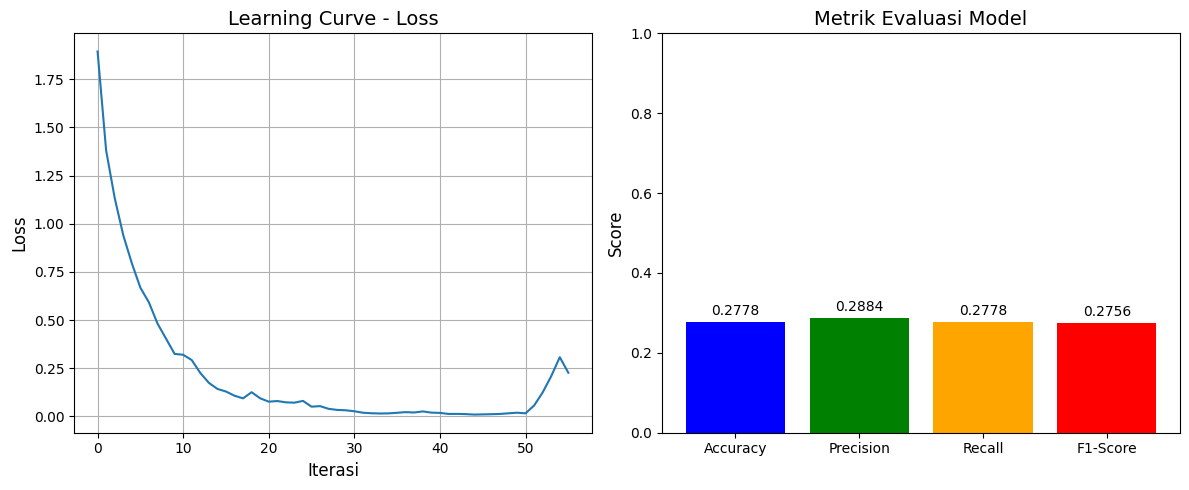

In [15]:
# Plot learning curve
plt.figure(figsize=(12, 5))

# Plot loss selama training
plt.subplot(1, 2, 1)
plt.plot(mlp.loss_curve_)
plt.title('Learning Curve - Loss', fontsize=14)
plt.xlabel('Iterasi', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.grid(True)

# Plot metrics
plt.subplot(1, 2, 2)
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
values = [accuracy, precision, recall, f1]
colors = ['blue', 'green', 'orange', 'red']

bars = plt.bar(metrics, values, color=colors)
plt.title('Metrik Evaluasi Model', fontsize=14)
plt.ylabel('Score', fontsize=12)
plt.ylim(0, 1)

# Tambahkan nilai di atas bar
for bar, value in zip(bars, values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{value:.4f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

In [16]:
import joblib
from datetime import datetime

# Buat folder untuk menyimpan hasil
output_dir = '/content/output'
os.makedirs(output_dir, exist_ok=True)

# Save model
joblib.dump(mlp, f'{output_dir}/mlp_model.pkl')
joblib.dump(scaler, f'{output_dir}/scaler.pkl')

print(f"Model dan scaler berhasil disimpan di folder: {output_dir}")

# Simpan hasil prediksi ke CSV
results_df.to_csv(f'{output_dir}/prediction_results.csv', index=False)
print("Hasil prediksi disimpan ke CSV")

Model dan scaler berhasil disimpan di folder: /content/output
Hasil prediksi disimpan ke CSV
